# Topic modeling with Latent Dirichlet Allocation

How LDA discovers themes in a document collection without labels, how to read and sanity-check the topics it finds, how to turn the per-document topic mixture into a feature vector for retrieval, and how coupling category-specific models through shared topics changes what is learned. We use a small Wikipedia-derived corpus and evaluate honestly, by held-out retrieval against known categories.

> Reference: Blei, Ng & Jordan, "Latent Dirichlet Allocation" (https://jmlr.csail.mit.edu/papers/v3/blei03a.html), JMLR 2003.


## The LDA generative model

Latent Dirichlet allocation makes topic modeling generative by drawing each document's topic proportions
from a shared Dirichlet prior. For document $d$: draw $\theta_d\sim\mathrm{Dirichlet}(\alpha)$; for each
token, draw a topic $z\sim\mathrm{Categorical}(\theta_d)$ and a word $w\sim\mathrm{Categorical}(\beta_z)$.
The topics $\beta_z$ are corpus-wide.

Theorem (LDA is the generative completion of PLSI). PLSI is recovered as the maximum-likelihood point
estimate of $\theta_d$ in LDA with a flat prior; adding the Dirichlet prior turns the free per-document
parameters into latent variables drawn from a shared law. The parameter count no longer grows with the
corpus, and any new document is generated by the same process, so LDA assigns it a probability and
generalizes.

Connection to exchangeability. By de Finetti's theorem (the conjugate-Bayes notebook), the words in a
document, treated as exchangeable, must be a mixture of iid draws over some latent measure; the Dirichlet
plus topics is exactly such a mixing representation. The bag-of-words model is the price: word order is
discarded, which is the exchangeability assumption made explicit.

## Inference is intractable, and evaluation is subtle

Theorem (the posterior is intractable). The exact posterior $p(\theta,z\mid w,\alpha,\beta)$ has a
normalizing constant that couples $\theta$ and $z$ and cannot be computed in closed form; exact inference
is intractable. Practical fitting uses variational EM (a factorized $q$, maximizing the ELBO) or collapsed
Gibbs sampling (integrating $\theta,\beta$ out and sampling the token topics).

Counterexamples and cautions. Topics are identifiable only up to relabeling (label switching), as for any
latent-variable model. And evaluation is genuinely subtle: held-out perplexity and human-judged topic
quality can disagree, the finding behind "reading tea leaves" (Chang et al. 2009), which is why the NPMI
topic-coherence measure (the applied section) is used alongside likelihood. Finally, the bag-of-words
assumption discards syntax, so LDA captures themes but not grammar or word order.

## 1. The problem: structure without labels

You have thousands of documents and no labels. You want to (a) discover what they are about, and (b) place a new document near similar ones. A bag-of-words vector is too sparse and high-dimensional to compare directly - two articles on the same subject often share few exact words.

Topic modeling posits a small number of latent topics - distributions over the vocabulary - and represents each document as a mixture of those topics. "Sport" might be a topic that puts weight on game, team, player, season; a document is then a short vector of topic proportions rather than a huge vector of word counts. Those proportions are the compact, comparable representation we are after.


## 2. The LDA generative model

LDA is a generative story for how each document's words arise. Fix $K$ topics. Each topic $k$ is a distribution $\beta_k$ over the $V$-word vocabulary. To generate a document $d$:

1. Draw its topic proportions $\theta_d \sim \mathrm{Dirichlet}(\alpha)$ - a point on the $K$-simplex.
2. For each word slot $n$: draw a topic $z_{d,n} \sim \mathrm{Categorical}(\theta_d)$, then draw the word $w_{d,n} \sim \mathrm{Categorical}(\beta_{z_{d,n}})$.

So the joint is

$$p(\theta, z, w \mid \alpha, \beta) = \prod_d \Big[ p(\theta_d \mid \alpha) \prod_n p(z_{d,n}\mid\theta_d)\, p(w_{d,n}\mid\beta_{z_{d,n}}) \Big].$$

The Dirichlet prior is what makes LDA more than a per-document mixture: $\alpha < 1$ favors sparse mixtures (each document uses few topics), which is what real documents look like. Fitting inverts the story - given the words, recover the topics $\beta$, the concentration $\alpha$, and each document's posterior proportions $\theta_d$. The posterior is intractable, so mixle fits it by variational EM (the E-step optimizes a per-document variational $\theta_d$; the M-step updates the shared topics). In mixle an `LDAEstimator` takes one categorical estimator per topic; documents are bag-of-words count lists.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

from mixle.stats import IntegerCategoricalEstimator, LDAEstimator, LDADistribution, ConditionalDistributionEstimator
from mixle.inference import initialize
from mixle.inference.estimation import optimize
from mixle.utils.evaluation import partition_data
import mixle.utils.optsutil as ops

DATA = '../../data'
t0 = time.time()

## 3. The corpus: Wikipedia categories

`data/wiki_example` holds short documents grouped by seed article (Mathematics, Medicine, Sports, War, …). We tokenize on whitespace, drop a MALLET stop list (high-frequency function words that carry no topical signal), and split each category 90/10 into train/test. The category label is kept only for evaluation - the unsupervised model never sees it.


In [2]:
def load_stop_words(path):
    # MALLET stop list -> a set of tokens to drop (plus the empty string)
    with open(path, 'rt') as fh:
        return set(fh.read().split('\n')) | {''}

def load_corpus(wiki_dir, stop, rng, test_frac=0.1):
    # Return (train, test) lists of (category_label, [tokens]) documents.
    # Each .txt file is one category; each line is one document. We split every
    # category by the same fraction so train and test share the label distribution.
    train, test = [], []
    for fname in sorted(f for f in os.listdir(wiki_dir) if f.endswith('.txt')):
        label = fname[:-4].lower()
        docs = [(label, [w for w in line.split(' ') if w not in stop])
                for line in ops.text_file(os.path.join(wiki_dir, fname))]
        tr, te = partition_data(docs, [1 - test_frac, test_frac], rng)
        train += tr; test += te
    drop_empty = lambda docs: [d for d in docs if d[1]]
    return drop_empty(train), drop_empty(test)

rng = np.random.RandomState(1)
stop = load_stop_words(os.path.join(DATA, 'stop_words', 'mallet.txt'))
train_docs, test_docs = load_corpus(os.path.join(DATA, 'wiki_example'), stop, rng)

# integer-encode the vocabulary and convert each document to (word_id, count) pairs
word_map = {}
to_counts = lambda toks: list(ops.count_by_value(ops.map_to_integers(toks, word_map)).items())
train_cnt = [(lbl, to_counts(toks)) for lbl, toks in train_docs]
test_cnt  = [(lbl, to_counts(toks)) for lbl, toks in test_docs]
word_inv = ops.get_inv_map(word_map)

categories = sorted({lbl for lbl, _ in train_docs})
cat_id = {c: i for i, c in enumerate(categories)}
train_labels = np.array([cat_id[lbl] for lbl, _ in train_cnt], dtype=object)
test_labels  = np.array([cat_id[lbl] for lbl, _ in test_cnt], dtype=object)
print('vocabulary: %d words | train docs: %d | test docs: %d | categories: %d'
      % (len(word_map), len(train_cnt), len(test_cnt), len(categories)))
print('categories:', categories)

vocabulary: 19078 words | train docs: 793 | test docs: 86 | categories: 9
categories: ['death', 'entertainment', 'food', 'investing', 'mathematics', 'medicine', 'politics', 'sports', 'war']


## 4. Fitting unsupervised LDA

We fit $K=10$ topics with variational EM. `initialize` seeds the topics randomly; `iterate` runs the variational E-step / M-step loop. We watch the training log-likelihood climb - its leveling off is the practical convergence signal, and a useful diagnostic in its own right (a curve that is still rising means more iterations would help; one that is flat-then-jumpy can signal a too-large $K$).


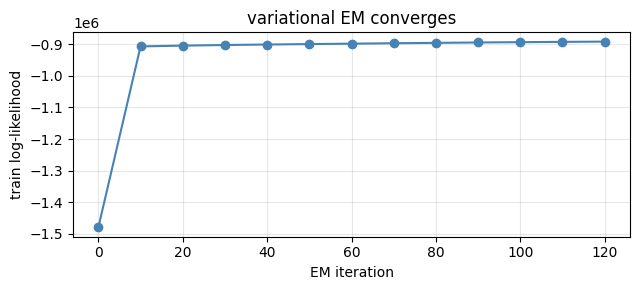

In [3]:
K = 10
base = IntegerCategoricalEstimator(min_val=0, max_val=len(word_map) - 1, pseudo_count=1e-3)
lda_est = LDAEstimator([base] * K, gamma_threshold=1e-2)

docs = [c for _, c in train_cnt]
model = initialize(docs, lda_est, np.random.RandomState(1), 0.1)

enc = model.dist_to_encoder().seq_encode(docs)
ll_trace = [np.sum(model.seq_log_density(enc))]
for _ in range(12):                       # 12 blocks x 10 iters = 120 EM iterations
    model = optimize(docs, lda_est, 10, prev_estimate=model, print_iter=100)
    enc = model.dist_to_encoder().seq_encode(docs)
    ll_trace.append(np.sum(model.seq_log_density(enc)))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(np.arange(len(ll_trace)) * 10, ll_trace, 'o-', color='steelblue')
ax.set_xlabel('EM iteration'); ax.set_ylabel('train log-likelihood')
ax.set_title('variational EM converges'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Reading the topics

A fitted topic is a distribution over the vocabulary; its highest-probability words name it. This is the first thing to check on any topic model - do the topics make sense? Coherent, distinct word lists mean the model found real structure; duplicated or word-salad topics mean $K$ is wrong or the data is too small.


In [4]:
def show_topics(topics, n=10):
    for i, t in enumerate(topics):
        top = np.argsort(-t.log_p_vec)[:n]
        print('topic %2d: %s' % (i, ', '.join(word_inv[j] for j in top)))

show_topics(model.topics)

topic  0: mathematics, science, mathematical, theory, study, numbers, century, modern, number, logic
topic  1: disease, death, term, word, people, person, called, television, include, deaths
topic  2: sports, century, world, sport, ancient, bc, empire, greek, period, games
topic  3: investment, market, financial, money, capital, company, stock, finance, economic, interest
topic  4: plants, species, plant, food, game, fruit, world, football, league, seeds
topic  5: games, form, death, entertainment, media, forms, acid, term, game, mortis
topic  6: military, war, warfare, strategy, enemy, forces, weapons, term, strategic, operations
topic  7: blood, heart, body, time, oxygen, system, called, leisure, left, energy
topic  8: medical, medicine, food, health, science, care, diagnosis, disease, traditional, include
topic  9: political, government, state, system, states, power, public, democracy, politics, human


## 6. Evaluating by retrieval

Topic coherence is qualitative. For a quantitative, honest test we use retrieval: represent every document by its topic-proportion vector, then for each held-out test document rank the training documents by cosine similarity and ask how far down the list before we hit a document of the same category? Because the model never saw the labels, good retrieval means the unsupervised topic space genuinely recovered the category structure.

We summarize with hit@k - the fraction of test documents whose top-$k$ neighbors contain at least one same-category document - and plot the full hit curve over search depth.


unsupervised LDA       hit@1=0.581  hit@3=0.698  hit@5=0.802  hit@10=0.860


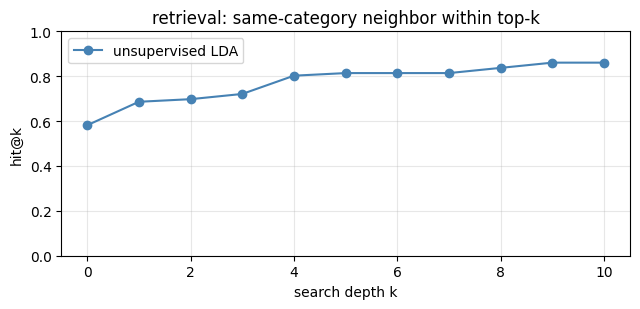

In [5]:
def topic_vectors(model, count_docs):
    # posterior topic proportions (one row per document), L1-normalized
    enc = model.dist_to_encoder().seq_encode(count_docs)
    locs = model.seq_posterior(enc)
    return locs / locs.sum(axis=1, keepdims=True)

def hit_curve(train_vecs, test_vecs, train_lab, test_lab, max_depth=10):
    # hit_curve[d] = P(a same-category doc appears within the top-(d+1) neighbors)
    sim = test_vecs @ train_vecs.T                      # cosine (vectors are normalized)
    order = np.argsort(-sim, axis=1)
    found = np.zeros((len(test_lab), max_depth + 1))
    for i in range(len(test_lab)):
        same = (train_lab[order[i]] == test_lab[i]).astype(int)
        found[i] = np.cumsum(same)[:max_depth + 1] >= 1
    return found.mean(axis=0)

def report(name, curve):
    print('%-22s hit@1=%.3f  hit@3=%.3f  hit@5=%.3f  hit@10=%.3f'
          % (name, curve[0], curve[2], curve[4], curve[10]))

lda_curve = hit_curve(topic_vectors(model, docs),
                      topic_vectors(model, [c for _, c in test_cnt]),
                      train_labels, test_labels)
report('unsupervised LDA', lda_curve)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(range(11), lda_curve, 'o-', color='steelblue', label='unsupervised LDA')
ax.set_xlabel('search depth k'); ax.set_ylabel('hit@k'); ax.set_ylim(0, 1)
ax.set_title('retrieval: same-category neighbor within top-k'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Coupled conditional LDA: sharing a topic vocabulary

Now suppose we do know each training document's category and want to exploit it - but we still want a single, comparable topic space. mixle's keying system makes this one line: a `ConditionalDistributionEstimator` fits a separate LDA per category, but `keys=(None, 'topics')` ties the topic-word distributions across all of them. Each category gets its own Dirichlet concentration $\alpha$ (its own characteristic topic mixture) while every category is forced to describe documents with the same underlying topics.

This is a recurring modeling move: share the expensive, data-hungry part (the vocabulary-sized topics) and let cheap, per-group parameters (the $K$-vector $\alpha$) capture the differences. It is the same shrinkage logic as hierarchical models, applied to a latent vocabulary.


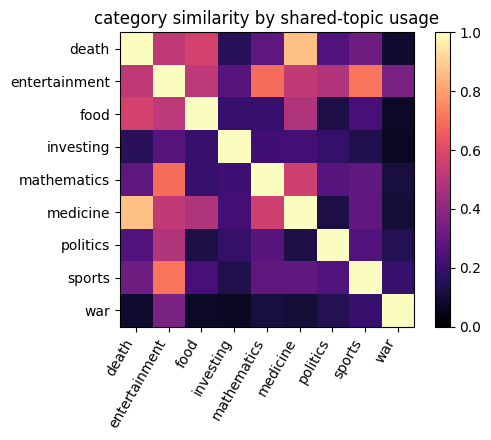

In [6]:
base = IntegerCategoricalEstimator(min_val=0, max_val=len(word_map) - 1, pseudo_count=1e-3)
shared = LDAEstimator([base] * K, keys=(None, 'topics'), gamma_threshold=1e-2)   # tie topic-word dists
cond_est = ConditionalDistributionEstimator({c: shared for c in categories})

cmodel = initialize(train_cnt, cond_est, np.random.RandomState(1), 0.1)
cmodel = optimize(train_cnt, cond_est, 120, prev_estimate=cmodel, print_iter=200)

# each category's alpha is its topic-usage signature; correlate them
alphas = np.array([cmodel.dmap[c].alpha for c in categories])
alphas /= np.linalg.norm(alphas, axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(alphas @ alphas.T, cmap='magma', vmin=0, vmax=1)
ax.set_xticks(range(len(categories))); ax.set_xticklabels(categories, rotation=60, ha='right')
ax.set_yticks(range(len(categories))); ax.set_yticklabels(categories)
ax.set_title('category similarity by shared-topic usage'); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

The off-diagonal structure is interpretable: categories that discuss overlapping topics (e.g. related subjects) score as more similar even though their topic vocabulary is shared - the difference lives entirely in how much each leans on each topic.

## 8. Does coupling help retrieval?

We compare three representations on the same retrieval task: (1) plain unsupervised LDA, (2) the coupled conditional model using each test document's category-conditional posterior, and (3) a single "average-$\alpha$" LDA built from the shared topics with the mean concentration - a control that isolates the value of the per-category $\alpha$.


unsupervised LDA       hit@1=0.581  hit@3=0.698  hit@5=0.802  hit@10=0.860
coupled conditional    hit@1=0.628  hit@3=0.674  hit@5=0.674  hit@10=0.721
average-alpha          hit@1=0.488  hit@3=0.709  hit@5=0.791  hit@10=0.884


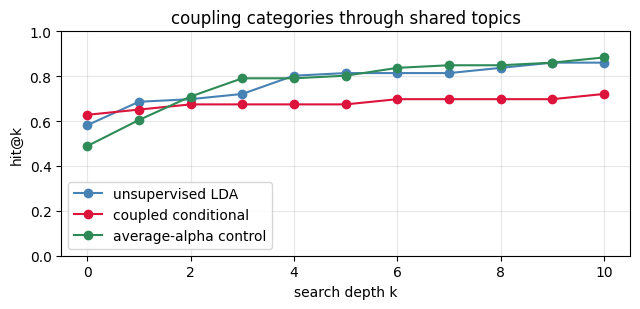


total runtime: 40 s


In [7]:
# conditional posteriors: score each TRAIN doc under its own category's model
def conditional_vectors(cmodel, labelled_cnt):
    vecs = [None] * len(labelled_cnt)
    by_cat = {}
    for i, (lbl, c) in enumerate(labelled_cnt):
        by_cat.setdefault(lbl, []).append((i, c))
    for lbl, items in by_cat.items():
        m = cmodel.dmap[lbl]
        locs = topic_vectors(m, [c for _, c in items])
        for (i, _), row in zip(items, locs):
            vecs[i] = row
    return np.array(vecs)

# test docs have no label at search time -> marginalize over categories by model evidence
def marginal_vectors(cmodel, count_docs):
    lls, locs = [], []
    for c in categories:
        m = cmodel.dmap[c]
        enc = m.dist_to_encoder().seq_encode(count_docs)
        lls.append(m.seq_log_density(enc)); locs.append(topic_vectors(m, count_docs))
    w = np.exp(np.array(lls) - np.max(lls, axis=0, keepdims=True)); w /= w.sum(axis=0, keepdims=True)
    return sum(w[k][:, None] * locs[k] for k in range(len(categories)))

mean_model = LDADistribution(cmodel.dmap[categories[0]].topics,
                             np.mean([cmodel.dmap[c].alpha for c in categories], axis=0))
cond_curve = hit_curve(conditional_vectors(cmodel, train_cnt),
                       marginal_vectors(cmodel, [c for _, c in test_cnt]), train_labels, test_labels)
avg_curve = hit_curve(topic_vectors(mean_model, docs),
                      topic_vectors(mean_model, [c for _, c in test_cnt]), train_labels, test_labels)
for nm, cv in [('unsupervised LDA', lda_curve), ('coupled conditional', cond_curve), ('average-alpha', avg_curve)]:
    report(nm, cv)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
for cv, lbl, c in [(lda_curve, 'unsupervised LDA', 'steelblue'),
                   (cond_curve, 'coupled conditional', 'crimson'),
                   (avg_curve, 'average-alpha control', 'seagreen')]:
    ax.plot(range(11), cv, 'o-', color=c, label=lbl)
ax.set_xlabel('search depth k'); ax.set_ylabel('hit@k'); ax.set_ylim(0, 1)
ax.set_title('coupling categories through shared topics'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('\ntotal runtime: %d s' % (time.time() - t0))

## NPMI topic coherence

The normalized pointwise mutual information (NPMI) coherence (Bouma 2009; Lau et al. 2014) is the modern standard, bounded in $[-1,1]$ and the best automatic proxy for human topic quality. For each topic we average NPMI over the top-word pairs, $\frac{\log p(w_i,w_j)/(p(w_i)p(w_j))}{-\log p(w_i,w_j)}$, estimated from document co-occurrence.


In [8]:
from collections import Counter
lda_docs = [c for _, c in train_cnt]
doc_sets = [set(w for w, _ in c) for c in lda_docs]
D = len(doc_sets); df = Counter(w for s in doc_sets for w in s)
def npmi(words):
    tot, m = 0.0, 0
    for i in range(1, len(words)):
        for j in range(i):
            pij = sum(1 for s in doc_sets if words[i] in s and words[j] in s) / D
            if pij == 0:
                tot += -1.0
            else:
                pi, pj = df[words[i]] / D, df[words[j]] / D
                tot += np.log(pij / (pi * pj)) / -np.log(pij)
            m += 1
    return tot / m
coh = {i: npmi(list(np.argsort(-t.log_p_vec)[:10])) for i, t in enumerate(model.topics)}
for i in sorted(coh, key=coh.get, reverse=True):
    print('topic %2d  NPMI = %+.3f   %s' %
          (i, coh[i], ', '.join(word_inv[j] for j in np.argsort(-model.topics[i].log_p_vec)[:6])))
print('mean NPMI = %+.3f  (closer to 1 is better; negative topics are incoherent).' % np.mean(list(coh.values())))

topic  6  NPMI = +0.396   military, war, warfare, strategy, enemy, forces
topic  3  NPMI = +0.389   investment, market, financial, money, capital, company
topic  9  NPMI = +0.230   political, government, state, system, states, power
topic  8  NPMI = +0.222   medical, medicine, food, health, science, care
topic  0  NPMI = +0.197   mathematics, science, mathematical, theory, study, numbers
topic  2  NPMI = +0.099   sports, century, world, sport, ancient, bc
topic  7  NPMI = -0.019   blood, heart, body, time, oxygen, system
topic  1  NPMI = -0.039   disease, death, term, word, people, person
topic  4  NPMI = -0.173   plants, species, plant, food, game, fruit
topic  5  NPMI = -0.208   games, form, death, entertainment, media, forms
mean NPMI = +0.109  (closer to 1 is better; negative topics are incoherent).


## References

- Blei, D. M., Ng, A. Y. & Jordan, M. I. (2003). Latent Dirichlet Allocation (https://jmlr.org/papers/v3/blei03a.html). JMLR 3, 993-1022.
- Griffiths, T. L. & Steyvers, M. (2004). Finding scientific topics (https://doi.org/10.1073/pnas.0307752101). PNAS 101(suppl. 1), 5228-5235. - collapsed Gibbs sampling.
- Wallach, H. M., Murray, I., Salakhutdinov, R. & Mimno, D. (2009). Evaluation methods for topic models (https://doi.org/10.1145/1553374.1553515). ICML. - held-out perplexity done right.
- Mimno, D. et al. (2011). Optimizing semantic coherence in topic models (https://aclanthology.org/D11-1024/). EMNLP. - topic coherence.
- Blei, D. M. (2012). Probabilistic topic models (https://doi.org/10.1145/2133806.2133826). CACM 55(4), 77-84.


## Exercises and extensions

1. Choosing the number of topics. Compare model selection by held-out perplexity (the left-to-right estimator, Wallach et al. 2009) against topic coherence (UMass / NPMI, Mimno et al. 2011); show they often disagree, and discuss why coherence tracks human judgment better.
2. Collapsed Gibbs vs variational. Implement the Griffiths-Steyvers (2004) collapsed Gibbs sampler and compare its topics, held-out likelihood, and runtime to mixle's variational LDA on the same corpus.
3. Topic coherence pipeline. Compute UMass, UCI, and NPMI coherence for the fitted topics and rank topics by coherence; manually inspect the best and worst and relate coherence to the §5 word lists.
4. Nonparametric number of topics. Use a hierarchical Dirichlet process (conjugate_and_nonparametric_bayes) to infer the number of topics rather than fixing $K$; compare to the perplexity/coherence-selected $K$.
